<center><span style="font-size:40px;"><b>NUTS vs HMC on GAUSSIAN 250D POSTERIOR</b></span></center>

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt   # backend symbolic math (used inside PyMC models)

import matplotlib.pyplot as plt
import time

from scipy.stats import wishart
from scipy.linalg import solve_triangular

from ucimlrepo import fetch_ucirepo # to load datasets from the UCI ML Repository

import xarray as xr  # Imported to handle multi-dimensional tracking safely

from tqdm.notebook import tqdm

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

In [2]:
D = 250      # number of dimensions
N = 1000     # number of draws
dof = 250     # number of degrees of freedom for precision matrix
warmup = 1000

delta_list = np.arange(0.20, 0.99, 0.02)
reps = 10
sample_settings = {"draws": N,
                   "tune" : warmup,
                   "chains": 4,
                   "start_seed": 2026,
                   "max_treedepth": 14
                  }

# But if we just treat the distribution as our posterior, we can simply draw from it with pyMC

A = wishart.rvs(df=dof, scale=np.eye(D), random_state=rng).astype(np.float64)

# Saving precision matrix to file for reproducibility
np.save("PrecisionMatrix.npy", A, allow_pickle=True)

In [3]:
# Monte Carlo Standard Error (MCSE) on realized mean acceptance rate
def mcse_batch_means(x, batch_size=None, min_batches=20):
    """
    We split the sinle input chain into m batches
    Compute the mean of each batch
    Treats those batch means as approximately independent
    Estimates variance from them
    """
    x = np.asarray(x, dtype=float).ravel()   # now this is a 1D array
    n = x.size                               # number of samples
    
    if batch_size is None:
        batch_size = int(np.sqrt(n))
    batch_size = max(1, int(batch_size))
    m = n // batch_size                      # m = number of batches
    
    if m < min_batches:   
        batch_size = max(1, n // min_batches) # ensures at least min_batches (default 20)
        m = n // batch_size
        
    if m < 2:  # safety check
        raise ValueError(f"Not enough data: n={n}, batch_size={batch_size}, batches={m}")

    # discards leftover samples so reshape works cleanly
    n_used = m * batch_size
    x_used = x[:n_used]
    
    # BATCH MEANS:
    batch_means = x_used.reshape(m, batch_size).mean(axis=1)   # we obtain m means
    mcse = batch_means.std(ddof=1) / np.sqrt(m)                # computes mcse with independent approx
    
    return mcse

def acc_rate_sweep_gauss( model, acceptance_rate_list, repetitions, sample_dict ):
    
    results = pd.DataFrame(columns=["Group", "Diff", "MCSE", "Min", "Mean", "Bulk Min", "Bulk Mean", "Grad Evals"])
    seed_offset = 0
    bins = np.arange(0, sample_dict["max_treedepth"]+2, 1) - 0.5
    # Store the counts of the reached depth: one row for each value of the target acceptance and one column for each frequency
    depth_counts = np.zeros(shape=(len(acceptance_rate_list), len(bins)-1 ))
    
    for i, target_accept in (enumerate(acceptance_rate_list)):
        print(f"Running Set {i+1}/{len(acceptance_rate_list)}")
        for _ in tqdm(range(repetitions)):
            with model:
                idata = pm.sample(  
                draws = sample_dict["draws"],     # number of posterior samples (after warmup)
                tune = sample_dict["tune"],      # number of warmup steps
                chains = sample_dict["chains"], 
                target_accept = target_accept,
                random_seed = sample_dict["start_seed"] + seed_offset,     # different seed for each run
                max_treedepth = sample_dict["max_treedepth"],
                progressbar = False,    # disable progress bar
                quiet = True,           # suppress sampler messages
                nuts_sampler = "pymc",  # use PyMC's NUTS implementation        
            )
            seed_offset += 1

            # extract acceptance rates and put them together for the same experiment
            acceptance = idata.sample_stats["acceptance_rate"].to_numpy()  
            h_chain = acceptance.reshape(-1,).mean()     # mean acceptance per experiment
            diff_chain = h_chain - target_accept  # deviation from target δ exeriment
            
            mcse = np.zeros(sample_dict["chains"]) # initialize MCSE array (per chain)
            # Loop over chains (Only for MCSE/Acceptance stats)
            for c in range(sample_dict["chains"]): 
                mcse[c] = mcse_batch_means(acceptance[c])  # estimate MCSE of mean acceptance for each chain

            # 2. Combine the MCSE error bars properly for independent chains
            combined_mcse = np.sqrt( (mcse**2).sum() )/ sample_dict["chains"]

            # ============== Computing ESS and Gradient Evaluations =============
    
            # Get the number of steps (POST WARM UP) 
            n_steps = idata.sample_stats["n_steps"].to_numpy()   # shape: (chains, draws)        
            
            # In the paper, ESS is normalized by the TOTAL amount of gradient evaluations across all samples
            total_grad_evals = n_steps.sum()  # Scalar: total gradient evaluations across all chains & draws

            # Like in the paper
            # 1. Compute Mean ESS
            ess_mean = az.ess(idata, method="mean")
            
            # 2. Compute Second Central Moment ESS
            # FIX: Keep data as an xarray Dataset so ArviZ preserves named dimensions for the 250D theta
            sq_diff_ds = xr.Dataset({
                "theta": (idata.posterior["theta"] - mu_true_theta)**2
            })
            ess_var = az.ess(sq_diff_ds, method="mean")

            # 3. Take the minimum between mean and variance for each dimension
            # Both ess_mean and ess_var are now clean xarray Datasets, so .values extracts the array properly
            ess_theta_min = np.minimum(ess_mean["theta"].values, ess_var["theta"].values)

            # Normalize by the total gradient evaluations
            ess_per_grad_theta = ess_theta_min / total_grad_evals

            # Final Aggregation across dimensions to get a single number
            # Average across dimensions
            mean_ess_grad_theta = np.mean(ess_per_grad_theta)
            ESS_PER_GRAD_MEAN = mean_ess_grad_theta

            # Strict paper methodology: take the absolute worst-case dimension
            ESS_PER_GRAD_MIN = np.min(ess_per_grad_theta)

             # Compute Bulk ESS natively
            ess_bulk = az.ess(idata, method="bulk")

            ess_theta_bulk = ess_bulk["theta"].values

            ess_per_grad_theta_bulk = ess_theta_bulk / total_grad_evals 

            # Final Aggregation across dimensions to get a single number
            # Average across dimensions
            mean_ess_grad_theta_bulk = np.mean(ess_per_grad_theta_bulk)
            ESS_PER_GRAD_MEAN_bulk = mean_ess_grad_theta_bulk

            # Strict paper methodology: take the absolute worst-case dimension
            ESS_PER_GRAD_MIN_bulk = np.min(ess_per_grad_theta_bulk)

            # Save results to dataframe
            tmp= pd.DataFrame({"Group" : i,
                            "Diff"  : diff_chain,
                            "MCSE"  : combined_mcse,
                            "Min"   : ESS_PER_GRAD_MIN,
                            "Mean"  : ESS_PER_GRAD_MEAN,
                            "Bulk Min": ESS_PER_GRAD_MIN_bulk,
                            "Bulk Mean": ESS_PER_GRAD_MEAN_bulk,
                            "Grad Evals": total_grad_evals
                           }, index = [0])
            
            results = pd.concat([results, tmp], ignore_index=True)

            depth = idata.sample_stats["tree_depth"].to_numpy().ravel()  # flatten chains+draws
            curr_counts, egdes = np.histogram(depth, bins = bins)
            depth_counts[i,:] += curr_counts
            
    return results, depth_counts

In [4]:
# ======================= MODEL DEFINITION =================
# We define the model logic inside a function so we can reuse it for both baseline and experiment runs
def create_Gauss_model(dimension, precision):
    with pm.Model() as model:  
        theta = pm.MvNormal("theta", mu=np.zeros(dimension), tau=precision, shape=dimension)
    return model


my_model = create_Gauss_model(D, A)

In [6]:
run_baseline = "no"                    

if run_baseline == "yes":
    # ======================= BASELINE RUN (50k Samples) =================
    
    print("Running baseline 50,000 samples to compute mu_true for the second central moment...")
    with my_model:
        baseline_idata = pm.sample(
            draws=50000, 
            tune=1000, 
            chains=1,                       # The paper runs a single long chain for the baseline
            target_accept=0.5,              # delta = 0.5 as specified in the paper
            random_seed=42,
            nuts_sampler="pymc",
            progressbar=True,
            max_treedepth = 14
        )
    # Extract the highly precise true means (mu_true)
    mu_true_theta = baseline_idata.posterior["theta"].mean(dim=["chain", "draw"]).values
    print("Baseline complete. mu_true calculated.")
    np.save("true_theta_Gauss.npy", mu_true_theta)



elif run_baseline == "no":
    mu_true_theta = np.load("true_theta_Gauss.npy")

In [7]:
# ============= RUNNING EXPERIMENTS ======================

start_time = time.perf_counter()   # debug

df, depths = acc_rate_sweep_gauss(my_model, delta_list, reps, sample_settings)


# DEBUG:
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Time elapsed: {elapsed_time:.4f} seconds")

Running Set 1/40


  0%|          | 0/10 [00:00<?, ?it/s]

Running Set 2/40


  0%|          | 0/10 [00:00<?, ?it/s]

Running Set 3/40


...

Running Set 39/40


  0%|          | 0/10 [00:00<?, ?it/s]

Running Set 40/40


  0%|          | 0/10 [00:00<?, ?it/s]

Time elapsed: 41128.5953 seconds


In [8]:
df.to_pickle("NUTS_GAUSS.pkl")
df.head(15)

,Group,Diff,MCSE,Min,Mean,Bulk Min,Bulk Mean,Grad Evals
0,0,-0.111395,0.001734,0.000002,0.000014,0.000003,0.000067,2226305.0
1,0,-0.06203,0.002136,0.000002,0.000007,0.000003,0.00004,2161165.0
2,0,-0.001333,0.00251,0.000163,0.000261,0.000163,0.000264,2902592.0
3,0,-0.101836,0.002043,0.000003,0.000006,0.000004,0.000008,1510666.0
4,0,-0.074258,0.001994,0.000003,0.00001,0.000005,0.000012,1361893.0
5,0,-0.117621,0.001664,0.000004,0.00001,0.000004,0.000015,1346254.0
6,0,-0.065636,0.002278,0.000003,0.000028,0.000003,0.00014,2286765.0
7,0,-0.134698,0.001606,0.000006,0.000013,0.000008,0.000013,678896.0
8,0,0.028861,0.002819,0.000003,0.000019,0.000004,0.000113,2310635.0
9,0,-0.024251,0.002719,0.000186,0.000279,0.000187,0.000285,3036352.0


# RESULTS VISUALIZATION

### DISTANCE FROM TARGET VALUE $\delta$

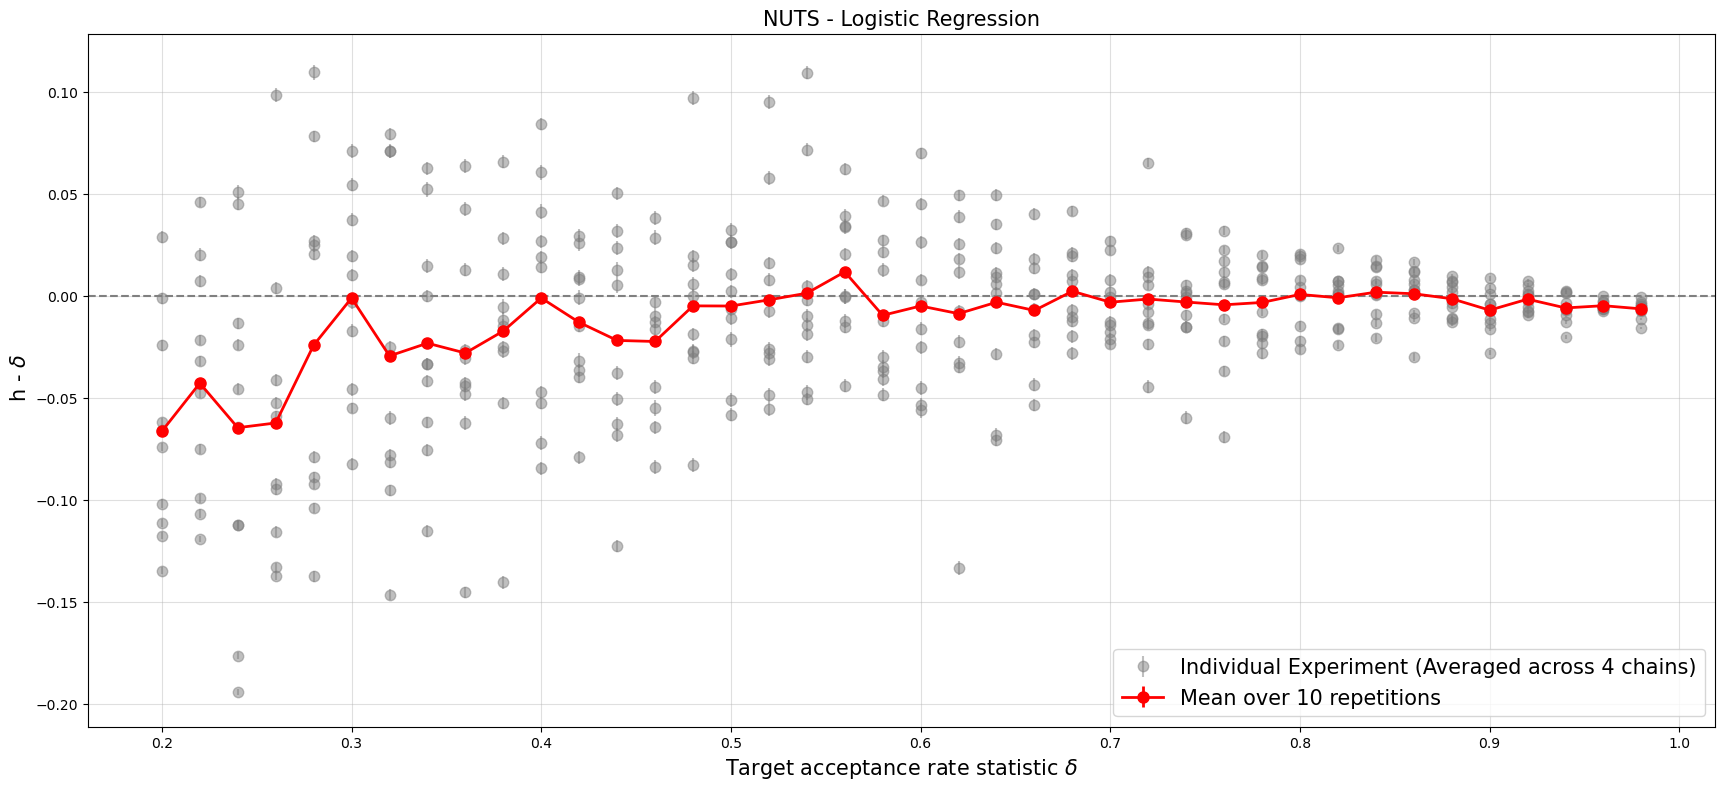

In [10]:
x_in_graph = [delta_list[i] for i in df["Group"].values]

# Plotting the single-experiment representation
fig, ax = plt.subplots(figsize=(21,9))

# Plot with errorbars using the combined metrics
ax.errorbar(
    x = x_in_graph, 
    y = df["Diff"], 
    yerr = df["MCSE"], 
    ls="None", 
    marker=".", 
    ms=15, 
    label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
    color="gray",
    alpha = 0.5
)

ax.errorbar(x = delta_list,
            y = df.groupby(by="Group").mean()["Diff"],
            yerr = df.groupby(by="Group")["MCSE"].apply(lambda x: np.sqrt( (x**2).sum()) / reps ),
            ls = "-",
            marker = "o",
            ms = 8,
            label = f"Mean over {reps} repetitions",
            color="red",
            lw = 2
)

plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
plt.ylabel(r" h - $\delta$", fontsize=15)
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.legend(loc="lower right", fontsize=15)
plt.axhline(y=0.0, ls="--", color="gray")
plt.grid(alpha=0.4)
plt.show()

### ESS / Grad

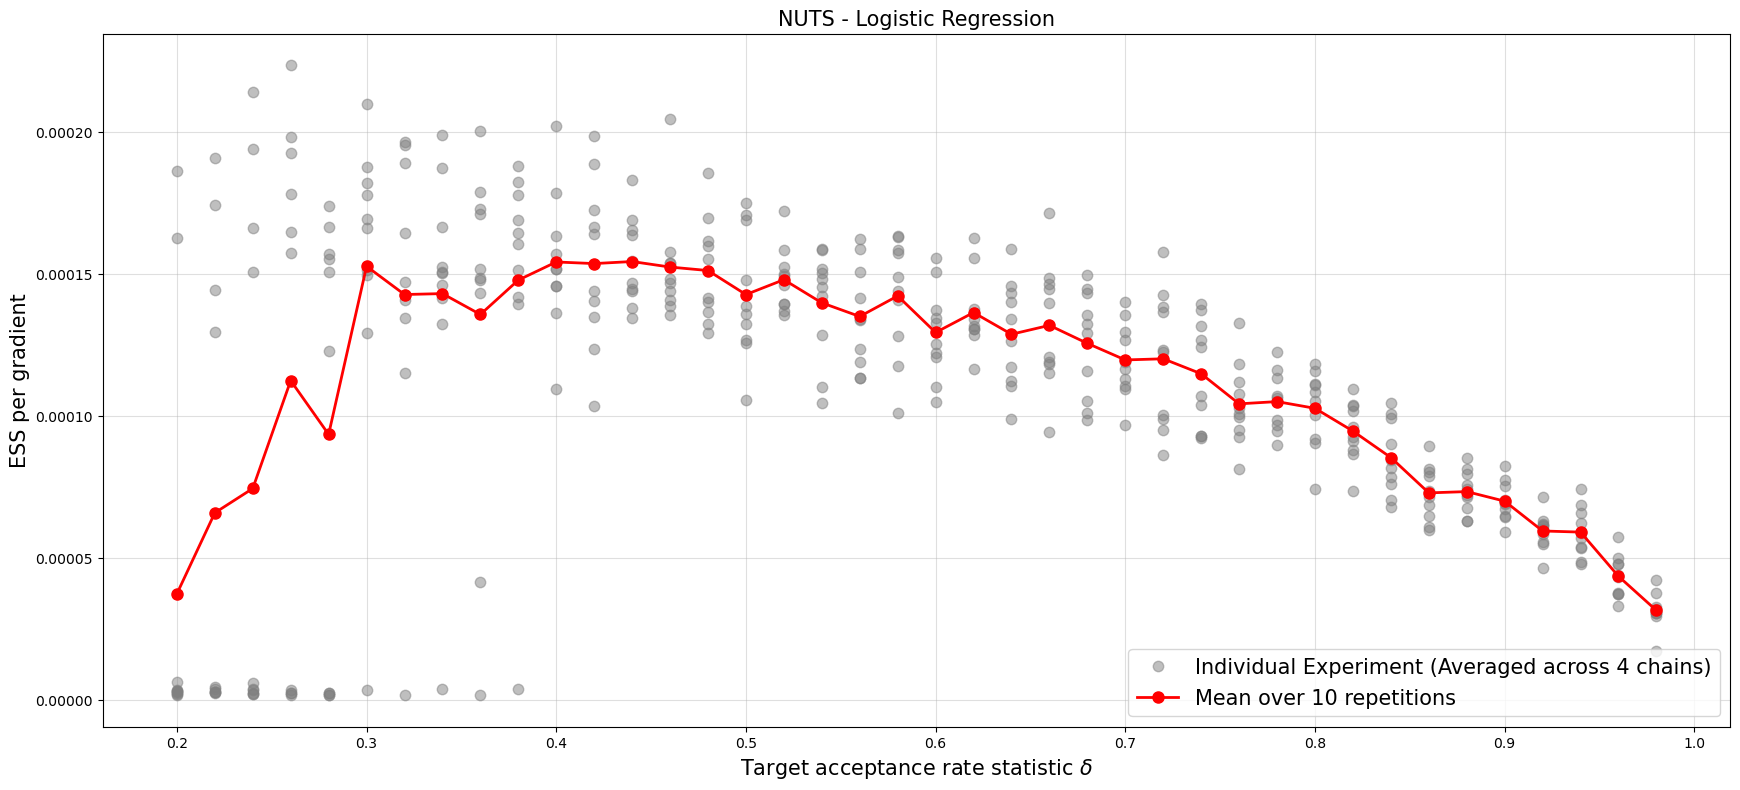

In [11]:
# Plotting the single-experiment representation
fig, ax = plt.subplots(figsize=(21,9))

# Plot with errorbars using the combined metrics
ax.plot(
    x_in_graph, 
    df["Min"], 
    ls="None", 
    marker=".", 
    ms=15, 
    label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
    color="gray",
    alpha = 0.5
)

ax.plot(delta_list,
        df.groupby(by="Group").mean()["Min"],
        ls = "-",
        marker = "o",
        ms = 8,
        label = f"Mean over {reps} repetitions",
        color="red",
        lw = 2
)

plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
plt.ylabel("ESS per gradient", fontsize=15)
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.legend(loc="lower right", fontsize=15)
plt.grid(alpha=0.4)
plt.show()

### TREE COUNTS

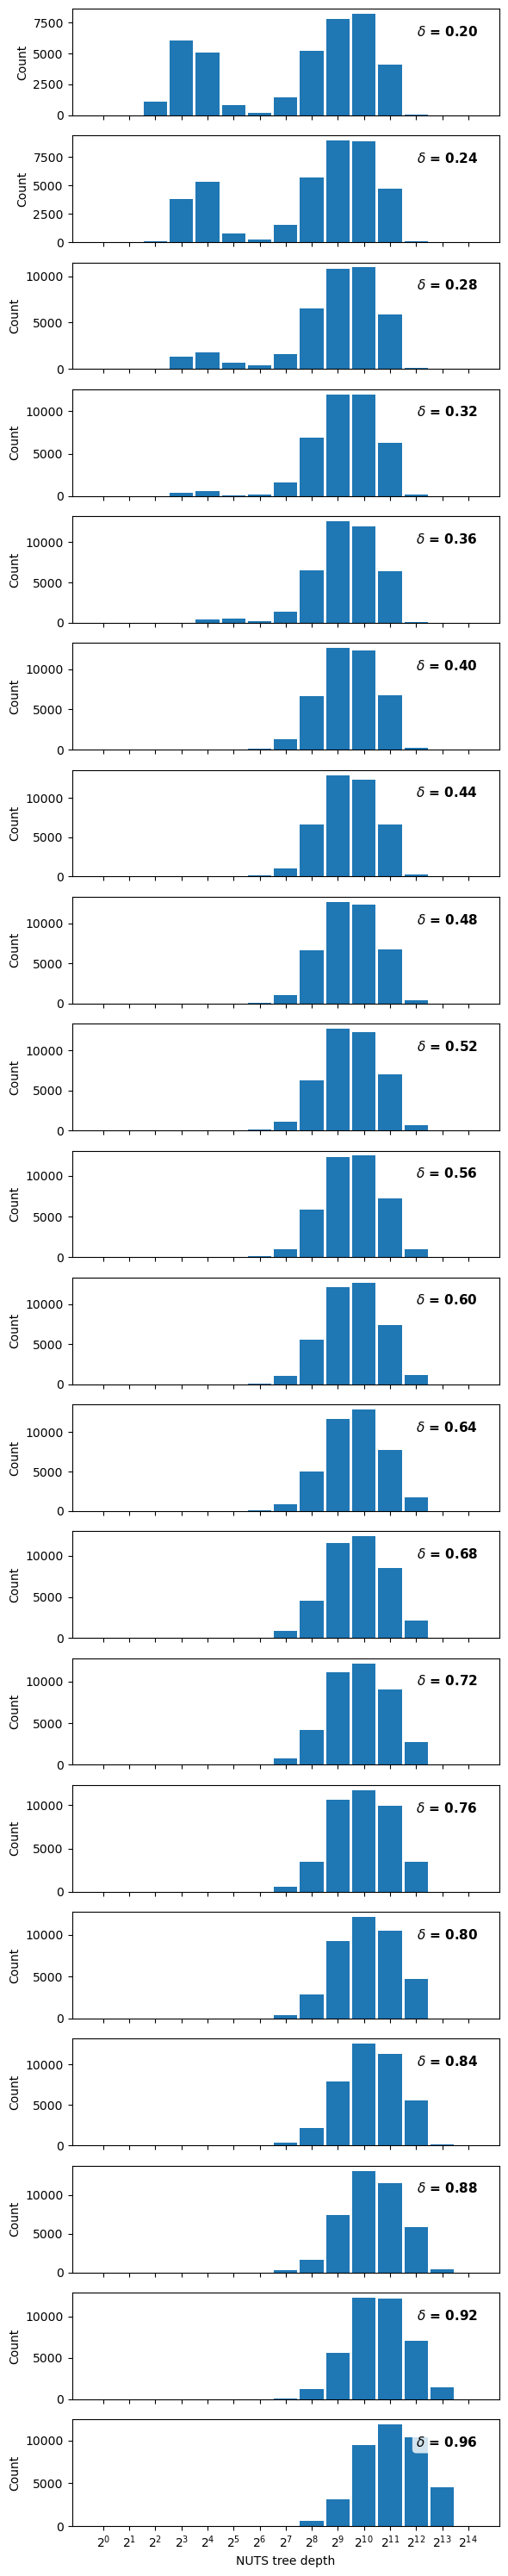

In [12]:
# Your index selection array
show_this_delta = np.arange(0, len(delta_list), 2, dtype="int")

# 1. Calculate number of vertical rows
n_rows = len(show_this_delta)

# 2. Create a single vertical column grid
# Each panel gets a height of 2.5 inches (adjust as you like)
fig, axes = plt.subplots(n_rows, 1, figsize=(6, 1.5 * n_rows), sharex=True)

# Handle the edge case where show_this_delta has only 1 element
if n_rows == 1:
    axes = [axes]

x_ticks = np.arange(0, sample_settings["max_treedepth"] + 1, 1)
x_labels = [fr"$2^{{{k}}}$" for k in range(sample_settings["max_treedepth"] + 1)]

# 3. Populate the vertical grid
for plot_idx, i in enumerate(show_this_delta):
    ax = axes[plot_idx]
    
    # Draw the bar chart
    ax.bar(x_ticks, depths[i], width=0.9, color="C0", edgecolor="none")
    
    # Always set ticks, but sharex=True will automatically hide labels for upper plots
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    
    # Y-Label for each specific panel
    ax.set_ylabel("Count")
    
    # Place delta text directly inside the plot panel (top right)
    ax.text(
        0.95, 0.85, 
        fr"$\delta$ = {delta_list[i]:.2f}", 
        transform=ax.transAxes, 
        horizontalalignment="right", 
        verticalalignment="top",
        fontsize=11,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none")
    )

# 4. Set the X-label only on the very last (bottom) subplot panel
axes[-1].set_xlabel("NUTS tree depth")

plt.tight_layout()
plt.show()

---

# HMC VERSION